In [ ]:
# ─── Save Model ───────────────────────────────────────────────────────────────
model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print(f"\nModel saved to {SAVE_DIR}")

# ─── Push model to HuggingFace ───────────────────────────────────────────────────────────────
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("HF_TOKEN")

login(token=secret_value_0)

model.push_to_hub("melisaolivia18/emotion-detection-roberta")
tokenizer.push_to_hub("melisaolivia18/emotion-detection-roberta")

In [1]:
import os
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("HF_TOKEN")

login(token=secret_value_0)  

In [2]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset
from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# ─── Config ───────────────────────────────────────────────────────────────────
MODEL_NAME = "roberta-base"
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 5
LR = 2e-5
SEED = 42
SAVE_DIR = "./model_output/emotion_detection"

In [4]:
# ─── Load Data ────────────────────────────────────────────────────────────────
df = pd.read_csv("/kaggle/input/datasets/melisaolivia/nlp-music-music-cleaned/cleaned_goemotions.csv") 

# Encode labels
EMOTION_CATEGORIES = ['anger', 'anxiety', 'calm', 'joy', 'sadness']
label2id = {l: i for i, l in enumerate(EMOTION_CATEGORIES)}
id2label = {i: l for l, i in label2id.items()}

df["label"] = df["emotion_label"].map(label2id)
df.dropna(subset=["label"], inplace=True)
df["label"] = df["label"].astype(int)

In [5]:
# ─── Split ────────────────────────────────────────────────────────────────────
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=SEED, stratify=df["label"])
val_df, test_df   = train_test_split(temp_df, test_size=0.5, random_state=SEED, stratify=temp_df["label"])
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")


Train: 1158 | Val: 145 | Test: 145


In [6]:
# ─── Dataset ──────────────────────────────────────────────────────────────────
tokenizer = RobertaTokenizer.from_pretrained(MODEL_NAME)

class EmotionDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(
            texts.tolist(),
            padding="max_length",
            truncation=True,
            max_length=MAX_LEN,
            return_tensors="pt"
        )
        self.labels = torch.tensor(labels.tolist(), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids":      self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels":         self.labels[idx]
        }

train_dataset = EmotionDataset(train_df["clean_text"], train_df["label"])
val_dataset   = EmotionDataset(val_df["clean_text"],   val_df["label"])
test_dataset  = EmotionDataset(test_df["clean_text"],  test_df["label"])

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [7]:
# ─── Model ────────────────────────────────────────────────────────────────────
model = RobertaForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(EMOTION_CATEGORIES), 
    id2label=id2label,
    label2id=label2id
)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [8]:
# ─── Metrics ──────────────────────────────────────────────────────────────────
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

In [9]:
# ─── Training Args ────────────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir=SAVE_DIR,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LR,
    eval_strategy="epoch",        # ← renamed from evaluation_strategy
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="./logs",
    logging_steps=50,
    seed=SEED,
    fp16=torch.cuda.is_available()
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [10]:
# ─── Trainer ──────────────────────────────────────────────────────────────────
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,2.966085,0.344828,0.118906,0.344828,0.176835
2,2.976150,2.837224,0.372414,0.237540,0.372414,0.234557
3,2.836849,2.666971,0.434483,0.339876,0.434483,0.366266
4,2.836849,2.553211,0.475862,0.384619,0.475862,0.423774
5,2.458882,2.560895,0.482759,0.468151,0.482759,0.429113


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=185, training_loss=2.6657349457611907, metrics={'train_runtime': 91.6522, 'train_samples_per_second': 63.174, 'train_steps_per_second': 2.019, 'total_flos': 380863511216640.0, 'train_loss': 2.6657349457611907, 'epoch': 5.0})

In [11]:
# ─── Evaluate on Test Set ─────────────────────────────────────────────────────
results = trainer.evaluate(test_dataset)
print("\n=== Test Set Results ===")
for k, v in results.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]



=== Test Set Results ===
  eval_loss: 2.7821
  eval_accuracy: 0.3862
  eval_precision: 0.3092
  eval_recall: 0.3862
  eval_f1: 0.3303
  eval_runtime: 0.7314
  eval_samples_per_second: 198.2530
  eval_steps_per_second: 6.8360
  epoch: 5.0000


In [12]:
# ─── Per-Class Report ──────────────────────────────
preds_output = trainer.predict(test_dataset)
preds       = np.argmax(preds_output.predictions, axis=1)
true_labels = preds_output.label_ids

print("\n=== Per-Class Classification Report ===")
print(classification_report(true_labels, preds, target_names=EMOTION_CATEGORIES, zero_division=0))

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]



=== Per-Class Classification Report ===
              precision    recall  f1-score   support

       anger       0.23      0.27      0.25        22
     anxiety       0.00      0.00      0.00        17
        calm       0.47      0.34      0.39        41
         joy       0.40      0.71      0.51        51
     sadness       0.00      0.00      0.00        14

    accuracy                           0.39       145
   macro avg       0.22      0.26      0.23       145
weighted avg       0.31      0.39      0.33       145



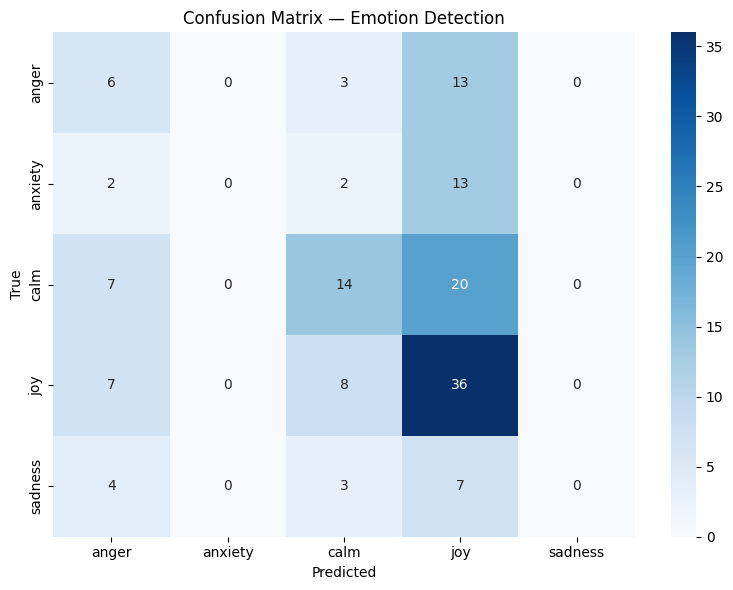

In [13]:
# ─── Confusion Matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(true_labels, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=EMOTION_CATEGORIES,  # fixed: was undefined label_list
            yticklabels=EMOTION_CATEGORIES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Emotion Detection")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()


In [14]:
# ─── Save Model ───────────────────────────────────────────────────────────────
model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print(f"\nModel saved to {SAVE_DIR}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model saved to ./model_output/emotion_detection


In [15]:
# ─── Push model to HuggingFace ───────────────────────────────────────────────────────────────
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("HF_TOKEN")

login(token=secret_value_0)

model.push_to_hub("melisaolivia18/emotion-detection-roberta")
tokenizer.push_to_hub("melisaolivia18/emotion-detection-roberta")

README.md: 0.00B [00:00, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/melisaolivia18/emotion-detection-roberta/commit/9c4ace087757475013dc4cd431fca9557dda79bb', commit_message='Upload tokenizer', commit_description='', oid='9c4ace087757475013dc4cd431fca9557dda79bb', pr_url=None, repo_url=RepoUrl('https://huggingface.co/melisaolivia18/emotion-detection-roberta', endpoint='https://huggingface.co', repo_type='model', repo_id='melisaolivia18/emotion-detection-roberta'), pr_revision=None, pr_num=None)